In [1]:
import h5py
import numpy as np

# To get the images and labels from file
ROOT_DIR = '../../../../Data/frischs/datasets/'
DATASET_FOLDER = 'Galaxy10_DECals/'
DATASET_NAME = 'Galaxy10_DECals.h5'

with h5py.File(ROOT_DIR + DATASET_FOLDER + DATASET_NAME, 'r') as F:
    images = np.array(F['images'])
    labels = np.array(F['ans'])


# To convert the labels to categorical 10 classes
def to_categorical(y, num_classes):
    """ 1-hot encodes a tensor """
    return np.eye(num_classes, dtype='uint8')[y]

#labels = to_categorical(labels, 10)


# To convert to desirable type
labels = labels.astype(np.float32)
images = images.astype(np.float32)

labels.shape, images.shape
#((17736, 10), (17736, 256, 256, 3))

((17736,), (17736, 256, 256, 3))

In [5]:
#np.bincount(labels.astype(np.int64))

unique_values = np.unique(labels.astype(np.int64))

# count the number of occurrences of each unique value
value_counts = np.bincount(labels.astype(np.int64))

# print the results
for value, count in zip(unique_values, value_counts):
    print(f"{value}: {count}")

0: 1081
1: 1853
2: 2645
3: 2027
4: 334
5: 2043
6: 1829
7: 2628
8: 1423
9: 1873


In [2]:
mean = np.mean(images, axis=(0, 1, 2))
std = np.std(images, axis=(0, 1, 2))


In [3]:
print('mean: ', mean)
print('std: ', std)

mean:  [3.6950834 3.6950834 3.6950834]
std:  [30.756159 28.62178  26.167793]


In [13]:
images.shape

(17736, 256, 256, 3)

In [14]:
#images = np.transpose(images, (0, 3, 1, 2))
images = images.astype(np.uint8)

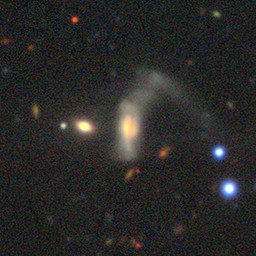

In [17]:
Image.fromarray(images[0])

In [11]:
from torchvision import transforms
from PIL import Image
train_transform = transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(224),
                transforms.Normalize(mean, std),
                transforms.ToTensor(),
                
            ])

images = images.astype(np.uint8)

for image in images:
    images = Image.fromarray(image) 
    print(type(image))
    train_transform(image).shape
    break

(256, 3, 256)


TypeError: Cannot handle this data type: (1, 1, 256), |u1